<a href="https://colab.research.google.com/github/MuhammadQasimTanveer/HerdOrbit-ML/blob/main/symptoms_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Symptoms Disease Prediction using XGBoost

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

print("Basic Setup completed")

Basic Setup completed


Add dataset loading and basic setup

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import joblib

# Load dataset
df = pd.read_excel('symptoms.xlsx')
print(df.head())

    Animal  Age  Temperature             Symptom 1         Symptom 2  \
0      cow    3        103.1              coughing   nasal discharge   
1  buffalo   13        104.5  enlarged lymph nodes      skin nodules   
2    sheep    1        100.5           watery eyes    painless lumps   
3      cow   14        100.3      loss of appetite  swelling in limb   
4    sheep    2        103.6       nasal discharge  loss of appetite   

          Symptom 3      Disease  
0  loss of appetite    pneumonia  
1    painless lumps  lumpy virus  
2      skin nodules  lumpy virus  
3   crackling sound     blackleg  
4          coughing    pneumonia  


Add data preprocessing and symptom combination

In [3]:
df['All_Symptoms'] = df['Symptom 1'].astype(str) + " " + df['Symptom 2'].astype(str) + " " + df['Symptom 3'].astype(str)
df = df.drop(['Symptom 1', 'Symptom 2', 'Symptom 3'], axis=1)
print(df.head())

    Animal  Age  Temperature      Disease  \
0      cow    3        103.1    pneumonia   
1  buffalo   13        104.5  lumpy virus   
2    sheep    1        100.5  lumpy virus   
3      cow   14        100.3     blackleg   
4    sheep    2        103.6    pneumonia   

                                        All_Symptoms  
0          coughing nasal discharge loss of appetite  
1   enlarged lymph nodes skin nodules painless lumps  
2            watery eyes painless lumps skin nodules  
3  loss of appetite swelling in limb crackling sound  
4          nasal discharge loss of appetite coughing  


Add label encoding for categorical features

In [4]:
# Ye cell X banane se PEHLE chalayein
from sklearn.preprocessing import LabelEncoder

le_animal = LabelEncoder()
le_symptoms = LabelEncoder()
le_disease = LabelEncoder()

# df pe encoding karein
df['Animal'] = le_animal.fit_transform(df['Animal'].astype(str))
df['All_Symptoms'] = le_symptoms.fit_transform(df['All_Symptoms'].astype(str))
df['Disease'] = le_disease.fit_transform(df['Disease'].astype(str))

print("✅ All columns encoded!")
print(df.dtypes)

✅ All columns encoded!
Animal            int64
Age               int64
Temperature     float64
Disease           int64
All_Symptoms      int64
dtype: object


Add train-test split and feature separation

In [5]:
X = df.drop('Disease', axis=1)
y = le_disease.fit_transform(df['Disease'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 Add XGBoost model training

In [6]:
from sklearn.preprocessing import LabelEncoder

# X ke object columns ko encode karein
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

print("✅ X encoded! Now training model...")

# Model dobara train karein
model = XGBClassifier(eval_metric='mlogloss', random_state=42)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ X encoded! Now training model...
✅ Model trained successfully!


In [7]:
print("Data types of X:")
print(X.dtypes)

Data types of X:
Animal            int64
Age               int64
Temperature     float64
All_Symptoms      int64
dtype: object


Add model evaluation and accuracy report

In [8]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))

Accuracy: 95.86%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1596
           1       1.00      1.00      1.00      1425
           2       1.00      1.00      1.00      1381
           3       0.98      0.97      0.98      1992
           4       0.90      0.88      0.89      2016
           5       0.89      0.90      0.90      1922
           6       0.96      0.98      0.97      1382
           7       0.96      0.98      0.97      1425

    accuracy                           0.96     13139
   macro avg       0.96      0.96      0.96     13139
weighted avg       0.96      0.96      0.96     13139



 Save Trained Model and Encoders

In [9]:
import joblib

joblib.dump(model, 'herd_orbit_xgb_model.pkl')
joblib.dump(le_animal, 'le_animal.pkl')
joblib.dump(le_symptoms, 'le_symptoms.pkl')
joblib.dump(le_disease, 'le_disease.pkl')

print("Model and encoders saved successfully.")

Model and encoders saved successfully.


Add Confusion Matrix Visualization

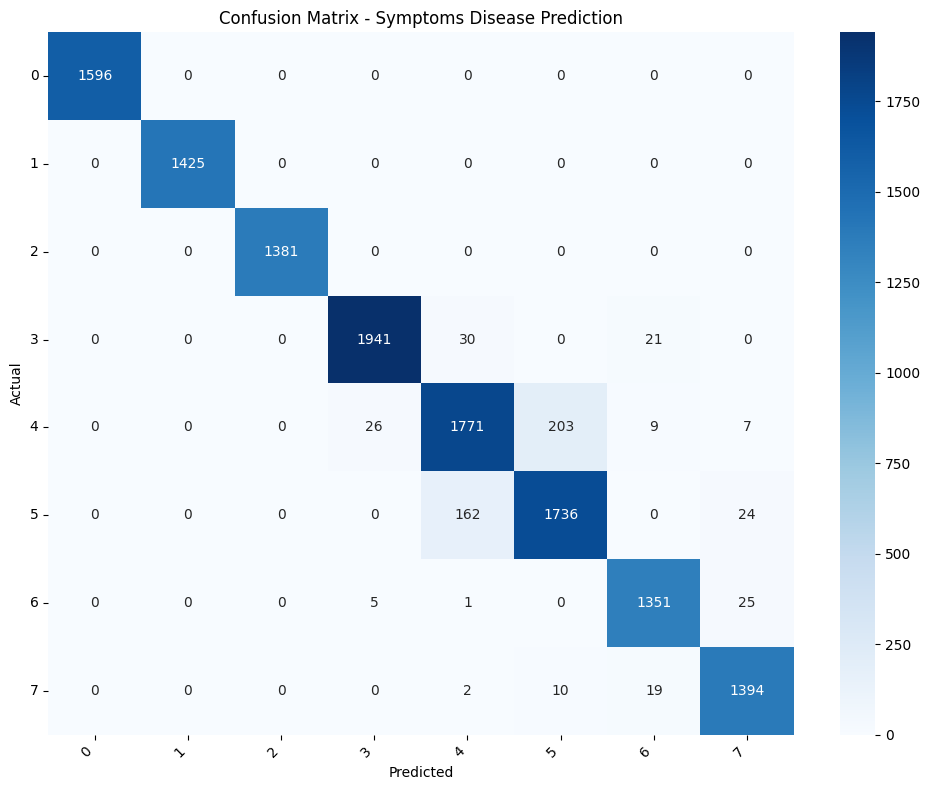

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_disease.classes_,
            yticklabels=le_disease.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Symptoms Disease Prediction')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()